# Análisis exploratorio (EDA): servicio de energía en las ZNI del suroccidente colombiano

Universidad Autónoma de Occidente · ETL · Simon Colonia Amador

Este cuaderno explora el **modelo gold** que construye el pipeline (las mismas tablas que se cargan a PostgreSQL) y responde las
seis preguntas del MVP del documento de diseño (sección 6.1). Está organizado así:

1. **Los datos**: qué hay, cuánto y con qué huecos.
2. **Calidad y cobertura** de las tres fuentes.
3. **Distribuciones y relaciones** entre variables.
4. **Las seis preguntas del MVP**: estado actual, brechas, evolución, operadores, PQR y peor desempeño.
5. **Contexto**: la bitácora de operación diaria.
6. **Conclusiones y límites**.

**Cómo está hecho.** Todas las gráficas son de **Matplotlib** (`src/eda/charts.py`). El título de cada una es su hallazgo, y *las cifras de cada lectura
se calculan a partir de los datos* (`src/eda/analysis.py`) en vez de escribirse a mano: si cambian los datos, esas cifras cambian con ellos.
Un color fijo por departamento en todo el cuaderno: Cauca (azul), Nariño (naranja), Valle del Cauca (verde) y Putumayo (amarillo).

> **Para ejecutarlo:** `python main.py --etapa gold` (si todavía no existe `data/gold`) y abrir el cuaderno con el kernel del entorno virtual `.venv`.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Markdown, display

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))

from src.eda import analysis as an
from src.eda import charts
from src.eda import style as st

pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)

g = an.cargar_gold()                 # tablas gold (data/gold)
op = an.cargar_operacion_diaria()    # silver/operacion_diaria (solo para la última sección)
H = an.calcular_hallazgos(g, op)     # cifras clave: de aquí salen los números del texto
fact = g["fact_prestacion"]
datos = an.horas_observadas(fact)   # observaciones localidad-mes con horas válidas


def md(texto):
    display(Markdown(texto))


def mostrar(nombre):
    """Dibuja una figura del registro con el tema del proyecto."""
    figura = charts.FIGURAS[nombre]
    with st.tema():
        fig = figura.funcion(g, op) if figura.requiere_operacion else figura.funcion(g)
    display(fig)


NOMBRES = {"19": "Cauca", "52": "Nariño", "76": "Valle del Cauca", "86": "Putumayo"}
num, horas = st.num, st.horas


def signo(valor, decimales=1):
    """'+0,3' / '−0,6' (el signo siempre explícito)."""
    return ("+" if valor >= 0 else "") + num(valor, decimales)

## 1. Los datos

El pipeline integra tres fuentes de datos.gov.co, filtradas a Valle del Cauca (76), Cauca (19), Nariño (52) y Putumayo (86):

| Fuente | Qué es | Granularidad | Rol |
|---|---|---|---|
| `prestacion` (3ebi-d83g) | Estado de la prestación del servicio de energía en ZNI (MinEnergía / IPSE) | localidad × mes | **base del análisis** (horas de servicio, energía, potencia) |
| `operacion_diaria` (qwe5-ycap) | Registro de operación diario (Superservicios) | localidad × día × generador | quién opera cada localidad |
| `pqr` (5wua-nr2d) | Reclamaciones y quejas (Superservicios) | caso individual → municipio-semestre | contexto municipal |

In [2]:
a = H["alcance"]
md(f"""
- `fact_prestacion` tiene **{num(a['observaciones'])} observaciones localidad-mes** de **{a['localidades']} localidades** en **{a['municipios_con_prestacion']} municipios**,
  de **{a['periodo_desde']}** a **{a['periodo_hasta']}** ({a['meses']} meses).
- El modelo gold completo tiene **{len(g)} tablas** (dimensiones, hechos, puente, indicadores y metadatos).
""")
fact.head(3).T


- `fact_prestacion` tiene **2.327 observaciones localidad-mes** de **97 localidades** en **14 municipios**,
  de **2020-01** a **2026-01** (73 meses).
- El modelo gold completo tiene **19 tablas** (dimensiones, hechos, puente, indicadores y metadatos).


,0,1,2
clave_localidad,19318008-LIMONES,19318008-LIMONES,19318008-LIMONES
id_localidad,19318008,19318008,19318008
id_municipio,19318,19318,19318
id_departamento,19,19,19
anio,2020,2020,2020
mes,8,9,10
periodo,2020-08-01 00:00:00,2020-09-01 00:00:00,2020-10-01 00:00:00
semestre,2,2,2
energia_activa,7673,8620,7396
energia_reactiva,1901,2316,2067


In [3]:
perfil = an.perfil_tabla(fact)
perfil[perfil["pct_nulos"] > 0][["columna", "tipo", "nulos", "pct_nulos"]]

,columna,tipo,nulos,pct_nulos
10,potencia_maxima,float64,96,4.13
11,potencia_maxima_reportada,float64,24,1.03
15,fecha_demanda_maxima,datetime64[us],24,1.03
19,id_operador,string,2132,91.62
20,nombre_operador,string,2132,91.62
21,n_operadores_localidad_mes,Int64,2132,91.62


In [4]:
fact[["energia_activa", "energia_reactiva", "potencia_maxima", "horas_servicio_promedio_dia"]].astype(float).describe().T

,count,mean,std,min,25%,50%,75%,max
energia_activa,"2,327.00","29,002.14","133,564.52",0.00,"3,236.50","5,252.00","8,472.50","1,067,174.00"
energia_reactiva,"2,327.00","9,998.85","42,827.29",0.00,"1,140.00","2,206.00","3,918.50","400,518.00"
potencia_maxima,"2,231.00",90.39,288.90,0.00,23.49,33.04,53.95,"3,229.16"
horas_servicio_promedio_dia,"2,327.00",7.41,4.01,0.00,5.53,7.04,8.38,24.00


In [5]:
nulos_potencia = perfil.set_index("columna").loc["potencia_maxima"]
con_cambio = fact[fact["potencia_invalida"]]
en_dic_ene = int(con_cambio["periodo"].dt.strftime("%Y-%m").isin(["2025-12", "2026-01"]).sum())
energia = fact["energia_activa"].astype(float)
md(f"""
**Lectura.** Las variables clave están completas, salvo `potencia_maxima` ({num(nulos_potencia['pct_nulos'], 1)} % de nulos = {int(nulos_potencia['nulos'])} filas): {len(con_cambio)} son filas con el
cambio de formato de la fuente ({en_dic_ene} de ellas en dic-2025 y ene-2026), cuya potencia no se puede corregir de forma fiable y se excluye (las horas sí se reescalaron), y las otras
{int(nulos_potencia['nulos']) - len(con_cambio)} ya vienen vacías de origen. Las medidas de energía son muy asimétricas (la media es {num(energia.mean() / energia.median(), 1)} veces la mediana),
lo que anticipa la concentración que se ve en la sección 3.
""")


**Lectura.** Las variables clave están completas, salvo `potencia_maxima` (4,1 % de nulos = 96 filas): 72 son filas con el
cambio de formato de la fuente (70 de ellas en dic-2025 y ene-2026), cuya potencia no se puede corregir de forma fiable y se excluye (las horas sí se reescalaron), y las otras
24 ya vienen vacías de origen. Las medidas de energía son muy asimétricas (la media es 5,5 veces la mediana),
lo que anticipa la concentración que se ve en la sección 3.


## 2. Calidad y cobertura de las fuentes

Antes de interpretar cualquier promedio hay que saber **qué tan completos y qué tan recientes** son los datos. Esta sección es el *preanálisis*:
cuánto llega cada fuente, cuántas localidades reportan cada mes y qué patrón tienen los huecos.

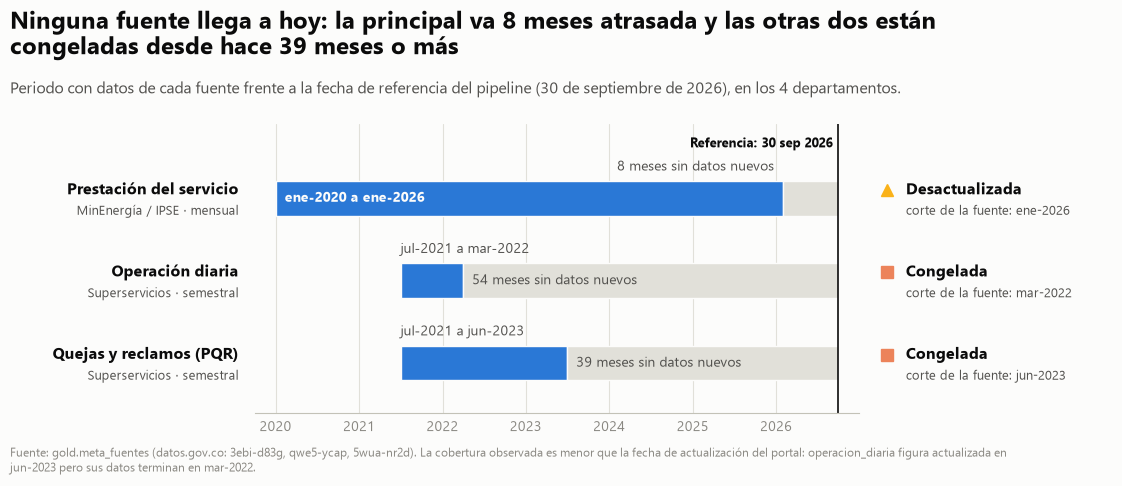

In [6]:
mostrar("fig01_frescura_fuentes")

In [7]:
f = {x["fuente"]: x for x in H["fuentes"]}
md(f"""
**Lectura.** `prestacion` (la fuente principal) llega hasta **{f['prestacion']['ultimo_periodo']}**: lleva **{f['prestacion']['meses_sin_datos_nuevos']} meses sin datos nuevos** a la fecha de referencia ({H['alcance']['fecha_referencia']}).
`operacion_diaria` y `pqr` están **congeladas** (últimos datos {f['operacion_diaria']['ultimo_periodo']} y {f['pqr']['ultimo_periodo']}). Por eso el modelo marca cada registro con su estado de
frescura y solo compara los periodos en que las fuentes son comparables.
""")


**Lectura.** `prestacion` (la fuente principal) llega hasta **2026-01**: lleva **8 meses sin datos nuevos** a la fecha de referencia (2026-09-30).
`operacion_diaria` y `pqr` están **congeladas** (últimos datos 2022-03 y 2023-06). Por eso el modelo marca cada registro con su estado de
frescura y solo compara los periodos en que las fuentes son comparables.


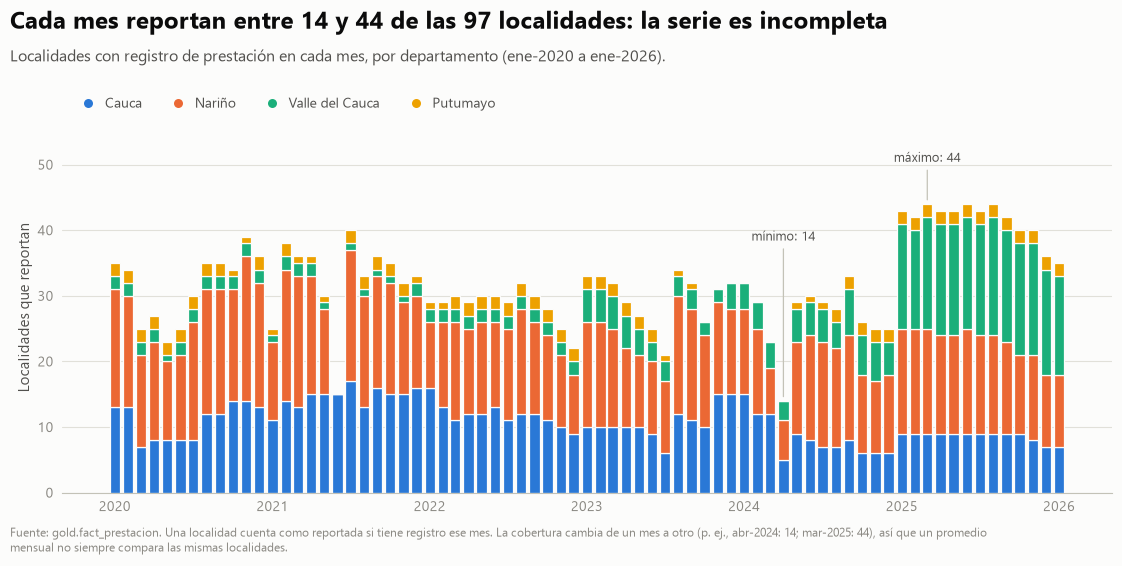

In [8]:
mostrar("fig02_cobertura_mensual")

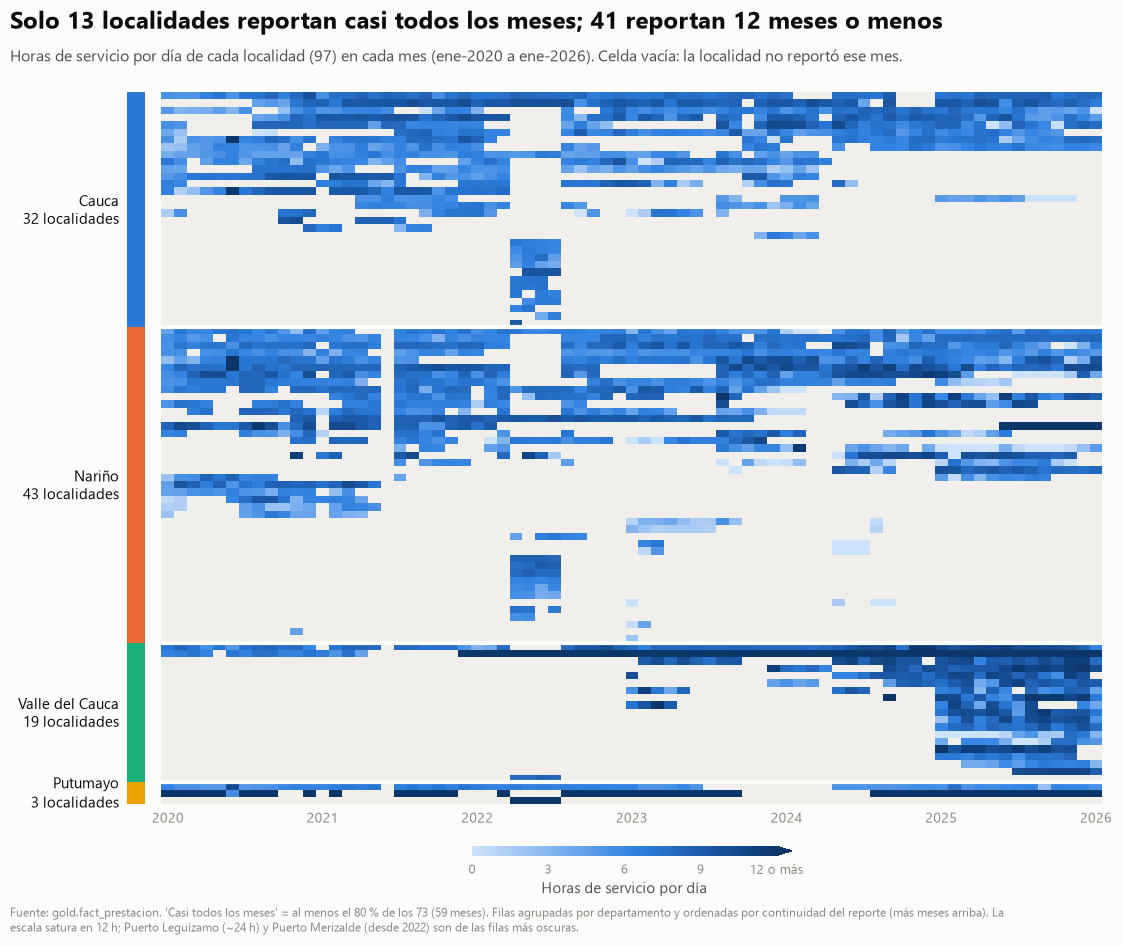

In [9]:
mostrar("fig03_mapa_reporte_localidades")

In [10]:
c = H["cobertura"]
md(f"""
**Lectura.** Cada mes reportan entre **{c['minimo']}** y **{c['maximo']}** de las {a['localidades']} localidades. Solo **{c['localidades_casi_todos_los_meses']}** reportan casi todos los meses y
**{c['localidades_12_meses_o_menos']}** reportan 12 meses o menos. El mapa de reporte muestra la causa: hay localidades que entran o salen de la serie (bloques que aparecen o desaparecen
de golpe) y otras que reportan de forma intermitente.

**Consecuencia para el análisis:** un promedio de "todas las observaciones" mezcla cambios reales del servicio con cambios de *qué localidades reportan*. Por eso, más adelante,
la evolución se mide comparando **cada localidad consigo misma**.
""")


**Lectura.** Cada mes reportan entre **14** y **44** de las 97 localidades. Solo **13** reportan casi todos los meses y
**41** reportan 12 meses o menos. El mapa de reporte muestra la causa: hay localidades que entran o salen de la serie (bloques que aparecen o desaparecen
de golpe) y otras que reportan de forma intermitente.

**Consecuencia para el análisis:** un promedio de "todas las observaciones" mezcla cambios reales del servicio con cambios de *qué localidades reportan*. Por eso, más adelante,
la evolución se mide comparando **cada localidad consigo misma**.


## 3. Distribuciones y relaciones entre variables

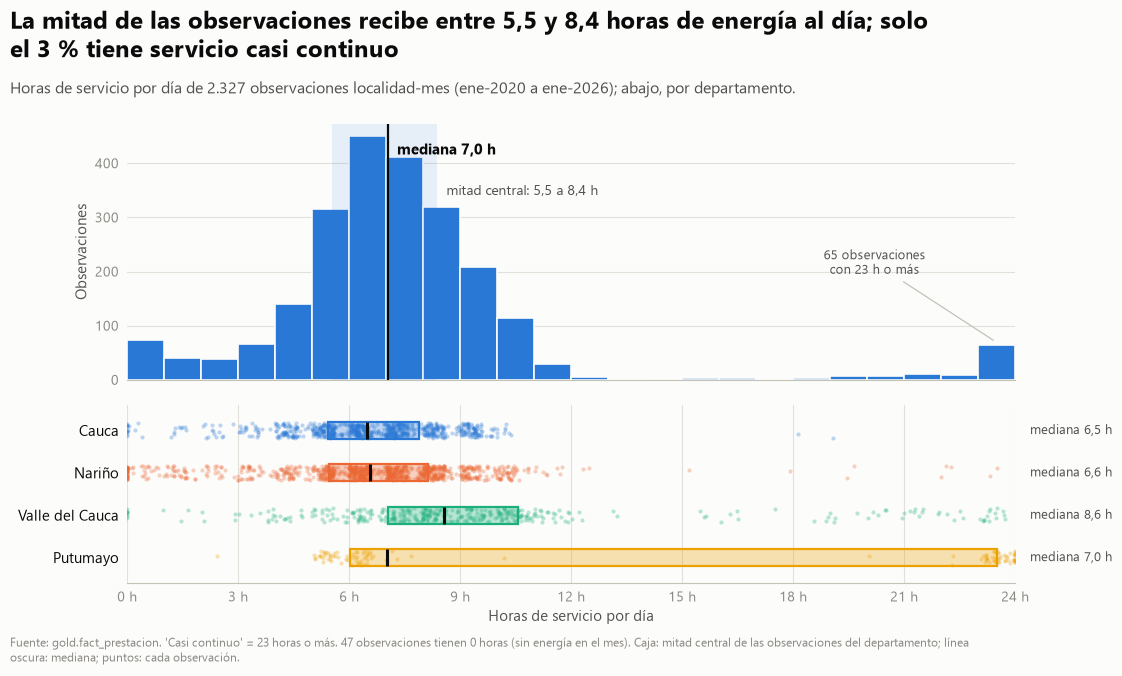

In [11]:
mostrar("fig04_distribucion_horas")

In [12]:
q1, q3 = datos["horas"].quantile([0.25, 0.75])
cerca = q3 + 1.5 * (q3 - q1)
lejos_abajo = q1 - 1.5 * (q3 - q1)
h = H["horas"]
md(f"""
**Lectura.** La mediana es de **{horas(h['mediana'])}** y la mitad de las observaciones está entre **{horas(h['p25'])}** y **{horas(h['p75'])}**: lejísimos de las 24 horas de un servicio continuo.
Por localidad, la mediana es de {horas(h['mediana_por_localidad'])}; **{h['localidades_menos_de_6_horas']}** de {a['localidades']} localidades promedian menos de 6 horas y solo **{h['localidades_12_horas_o_mas']}** llegan a 12 o más.

**Valores atípicos (regla del rango intercuartílico).** Por encima de {horas(cerca)} hay {int((datos['horas'] > cerca).sum())} observaciones (las localidades de servicio casi continuo) y por debajo de {horas(lejos_abajo)}
hay {int((datos['horas'] < lejos_abajo).sum())} (meses con muy poco servicio o sin él: {h['observaciones_sin_energia']} observaciones tienen 0 horas). **No son errores**: son el servicio real de esas localidades, y por eso no se eliminan.
""")


**Lectura.** La mediana es de **7,0 h** y la mitad de las observaciones está entre **5,5 h** y **8,4 h**: lejísimos de las 24 horas de un servicio continuo.
Por localidad, la mediana es de 6,7 h; **35** de 97 localidades promedian menos de 6 horas y solo **3** llegan a 12 o más.

**Valores atípicos (regla del rango intercuartílico).** Por encima de 12,6 h hay 113 observaciones (las localidades de servicio casi continuo) y por debajo de 1,3 h
hay 87 (meses con muy poco servicio o sin él: 47 observaciones tienen 0 horas). **No son errores**: son el servicio real de esas localidades, y por eso no se eliminan.


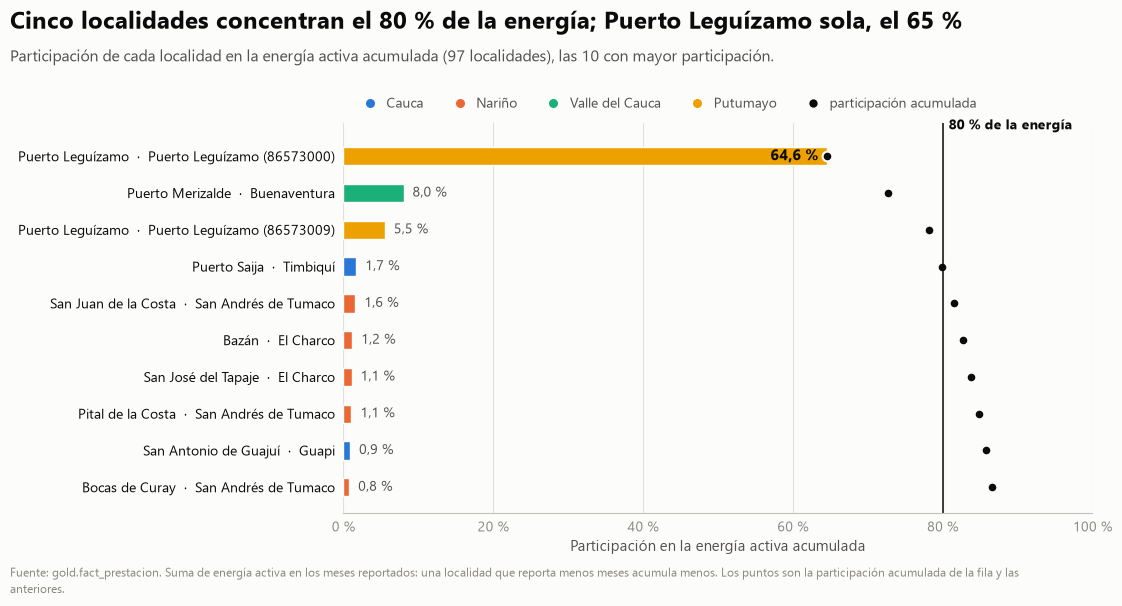

In [13]:
mostrar("fig05_concentracion_energia")

In [14]:
e = H["energia"]
md(f"""
**Lectura.** La energía está muy concentrada: **{e['localidades_para_80_pct']} localidades** acumulan el 80 % de la energía activa y **{e['localidad_principal']}** sola, el **{num(e['participacion_principal_pct'], 0)} %**.
Un promedio de energía entre localidades sería engañoso; por eso las comparaciones de servicio usan **horas por día** (comparables entre localidades) y no energía.
""")


**Lectura.** La energía está muy concentrada: **5 localidades** acumulan el 80 % de la energía activa y **Puerto Leguízamo** sola, el **65 %**.
Un promedio de energía entre localidades sería engañoso; por eso las comparaciones de servicio usan **horas por día** (comparables entre localidades) y no energía.


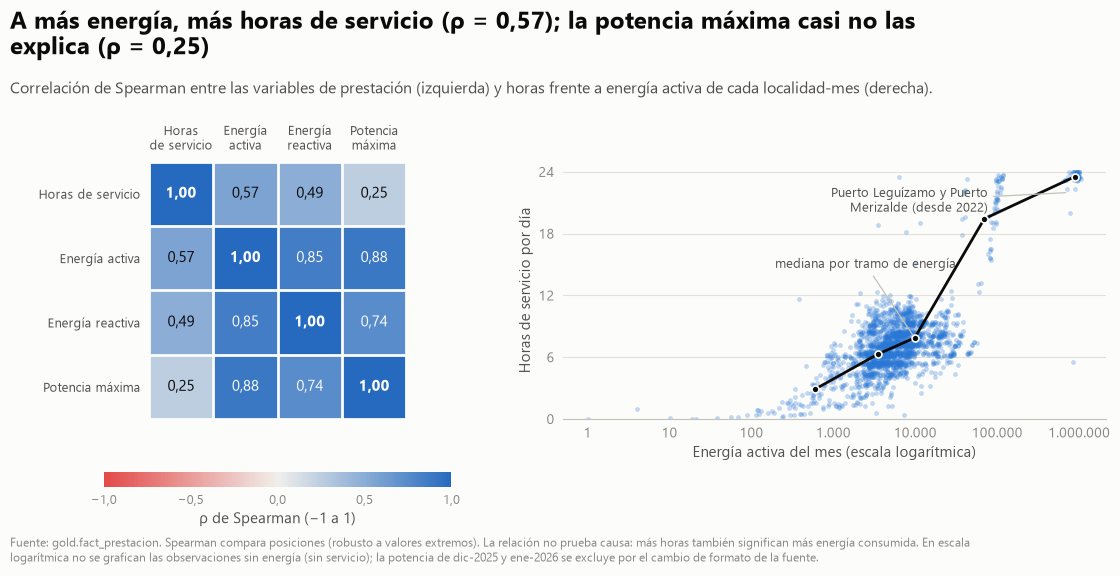

In [15]:
mostrar("fig06_correlaciones")

In [16]:
k = H["correlaciones"]
md(f"""
**Lectura.** Las horas de servicio se relacionan de forma moderada con la energía activa (ρ = {num(k['horas_energia_activa'], 2)}) y apenas con la potencia máxima (ρ = {num(k['horas_potencia_maxima'], 2)}):
una localidad puede tener una planta grande y aun así pocas horas de servicio. La relación con la energía es en parte circular (más horas, más energía consumida), así que no se interpreta como causa.
""")


**Lectura.** Las horas de servicio se relacionan de forma moderada con la energía activa (ρ = 0,57) y apenas con la potencia máxima (ρ = 0,25):
una localidad puede tener una planta grande y aun así pocas horas de servicio. La relación con la energía es en parte circular (más horas, más energía consumida), así que no se interpreta como causa.


## 4. Las seis preguntas del MVP

### P1 · ¿Cuál es el estado actual de la prestación del servicio?

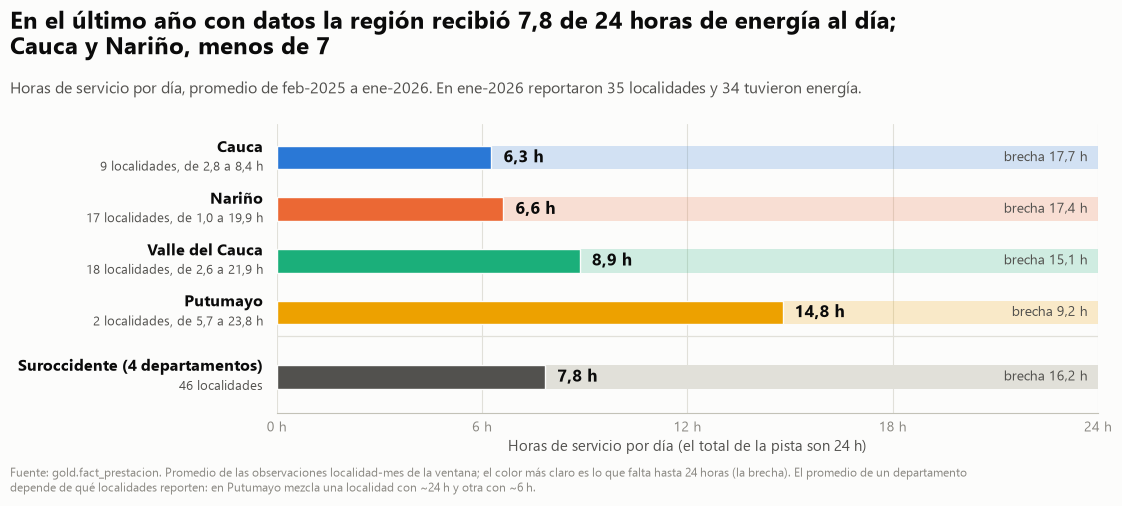

In [17]:
mostrar("fig07_estado_departamentos")

In [18]:
er = H["estado_reciente"]
dep = er["departamentos"]
um = er["ultimo_mes"]
ventana = datos[datos["periodo"] >= pd.Timestamp(er["ventana_desde"])]
putumayo = ventana[ventana["id_departamento"] == "86"].groupby("clave_localidad")["horas"].mean()
md(f"""
**Lectura.** En los últimos 12 meses con datos ({er['ventana_desde']} a {er['ventana_hasta']}) las localidades de la región recibieron en promedio **{horas(er['region']['horas'])} de 24 horas** de energía al día.
Cauca ({horas(dep['19']['horas'])}) y Nariño ({horas(dep['52']['horas'])}) están por debajo de 7 horas; Valle del Cauca tiene {horas(dep['76']['horas'])} y Putumayo {horas(dep['86']['horas'])}.
En **{um['periodo']}**, el último mes con datos, reportaron {um['localidades_reportadas']} localidades y {um['localidades_con_servicio']} tuvieron energía.

**Cuidado con Putumayo:** su promedio sale de solo {len(putumayo)} localidades, que van de {horas(putumayo.min())} a {horas(putumayo.max())}; un promedio entre extremos así no representa al departamento.
""")


**Lectura.** En los últimos 12 meses con datos (2025-02 a 2026-01) las localidades de la región recibieron en promedio **7,8 h de 24 horas** de energía al día.
Cauca (6,3 h) y Nariño (6,6 h) están por debajo de 7 horas; Valle del Cauca tiene 8,9 h y Putumayo 14,8 h.
En **2026-01**, el último mes con datos, reportaron 35 localidades y 34 tuvieron energía.

**Cuidado con Putumayo:** su promedio sale de solo 2 localidades, que van de 5,7 h a 23,8 h; un promedio entre extremos así no representa al departamento.


### P2 · ¿Qué departamentos y municipios concentran las mayores brechas?

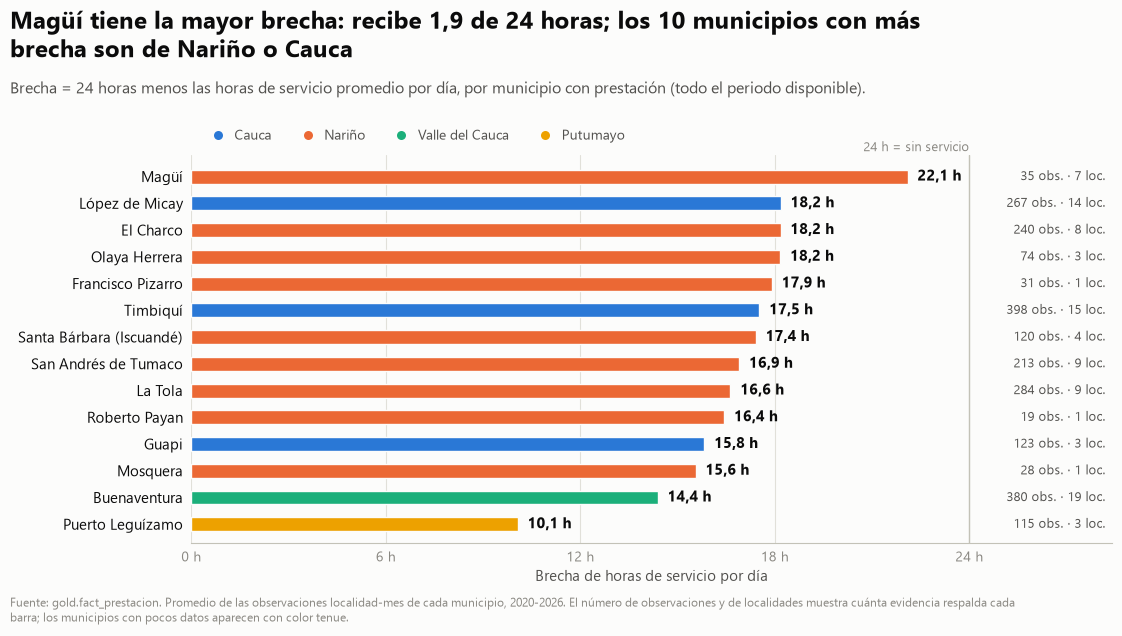

In [19]:
mostrar("fig08_brechas_municipios")

In [20]:
m = H["municipios_mayor_brecha"]
menores = H["municipios_menor_brecha"]
solo_narino_cauca = all(x["departamento"] in ("19", "52") for x in m)
resto = "Los " + str(len(m)) + " municipios con más brecha son de **Nariño o Cauca** (costa pacífica)." if solo_narino_cauca else "Entre los " + str(len(m)) + " con más brecha hay municipios de varios departamentos."
md(f"""
**Lectura.** La brecha es 24 horas menos las horas de servicio. **{m[0]['municipio']}** es el extremo: {horas(m[0]['horas'])} al día (brecha de {horas(m[0]['brecha'])}), con {m[0]['localidades']} localidades observadas.
Le siguen {m[1]['municipio']}, {m[2]['municipio']}, {m[3]['municipio']} y {m[4]['municipio']}, con brechas de {num(m[4]['brecha'], 1)} a {num(m[1]['brecha'], 1)} h. {resto}
Las menores brechas son las de {menores[0]['municipio']} ({horas(menores[0]['horas'])} de servicio) y {menores[1]['municipio']} ({horas(menores[1]['horas'])}).
""")


**Lectura.** La brecha es 24 horas menos las horas de servicio. **Magüí** es el extremo: 1,9 h al día (brecha de 22,1 h), con 7 localidades observadas.
Le siguen López de Micay, El Charco, Olaya Herrera y Francisco Pizarro, con brechas de 17,9 a 18,2 h. Los 10 municipios con más brecha son de **Nariño o Cauca** (costa pacífica).
Las menores brechas son las de Puerto Leguízamo (13,9 h de servicio) y Buenaventura (9,6 h).


### P3 · ¿Cómo ha evolucionado el servicio?

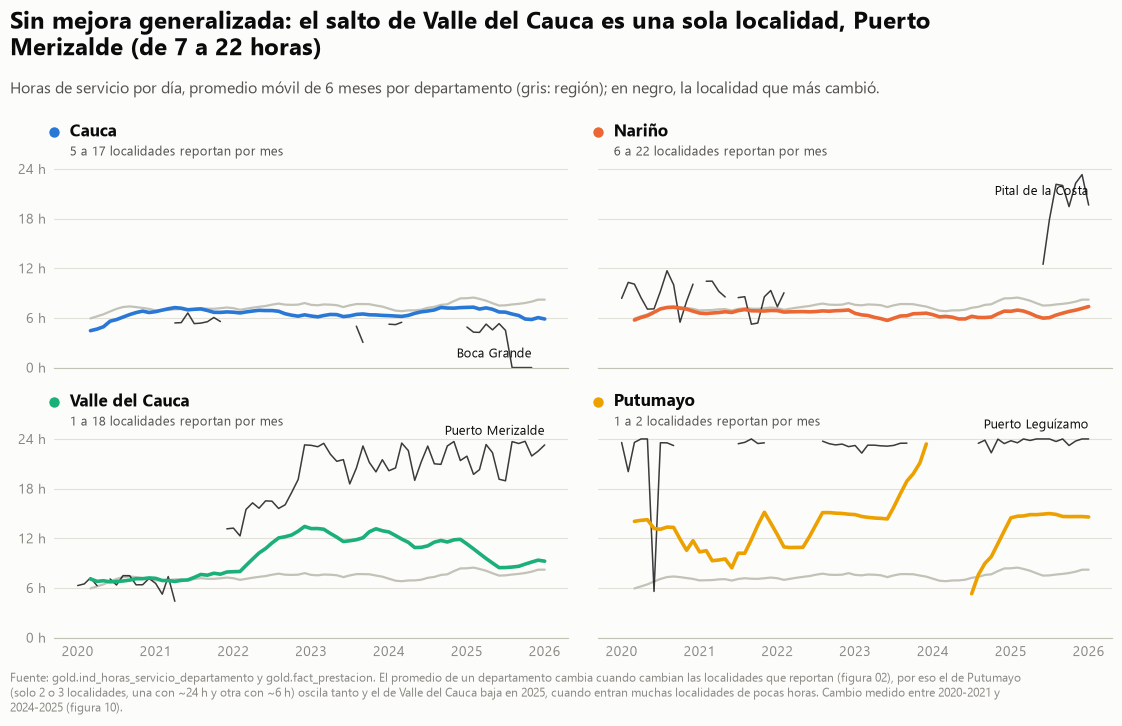

In [21]:
mostrar("fig09_evolucion_departamentos")

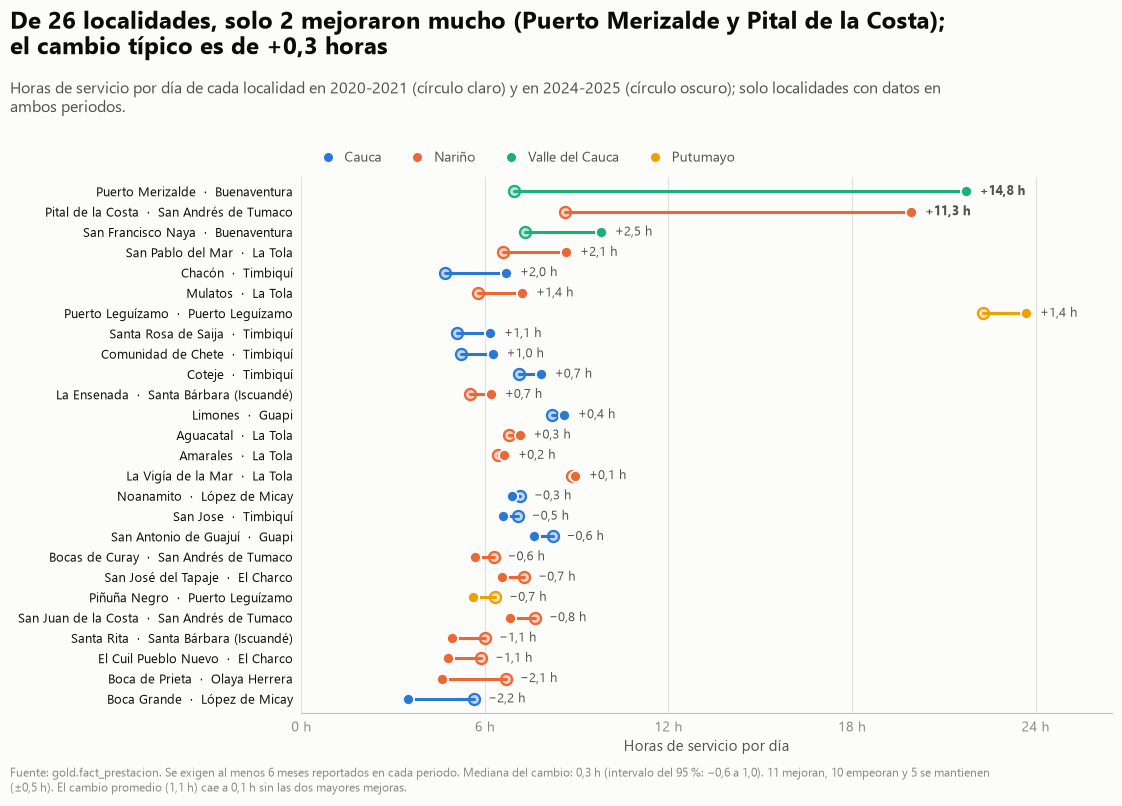

In [22]:
mostrar("fig10_cambio_localidades")

In [23]:
cl = H["cambio_por_localidad"]
mm = cl["mayores_mejoras"]
vi, vf = cl["ventana_inicial"], cl["ventana_final"]
md(f"""
**Lectura.** Las curvas por departamento (primera figura) cambian mucho, pero casi siempre porque cambian las localidades que reportan. El mayor salto de un departamento, el de
{NOMBRES[mm[0]['departamento']]}, lo explica **una sola localidad**: {mm[0]['localidad']} ({horas(mm[0]['antes'], 0)} → {horas(mm[0]['despues'], 0)}).

Para quitar ese efecto se compara **cada localidad consigo misma** entre {vi[0]}-{vi[-1]} y {vf[0]}-{vf[-1]} (segunda figura). De {cl['localidades']} localidades con datos en ambos periodos,
**{cl['mejoran']}** mejoran más de {horas(cl['umbral_horas'])}, **{cl['empeoran']}** empeoran y **{cl['se_mantienen']}** se mantienen. El cambio **mediano** es de {signo(cl['mediana'])} h
(intervalo de confianza del 95 %: {signo(cl['mediana_inferior'])} a {signo(cl['mediana_superior'])}): **{'no se distingue de cero' if cl['mediana_inferior'] <= 0 <= cl['mediana_superior'] else 'es distinto de cero'}**.
El cambio promedio ({signo(cl['media'])} h) lo jalonan dos localidades, {mm[0]['localidad']} y {mm[1]['localidad']}; sin ellas es de {signo(cl['media_sin_las_dos_mayores_mejoras'])} h.
Fuera de esas dos, la mayor mejora es de {signo(cl['tercera_mayor_mejora'])} h y el mayor retroceso de {signo(cl['mayor_retroceso'])} h.

**Conclusión:** no hay una mejora generalizada del servicio; hay **dos casos notables** que valdría la pena estudiar (¿qué cambió allí?) y, en el resto, mejoras y retrocesos pequeños que se compensan.
""")


**Lectura.** Las curvas por departamento (primera figura) cambian mucho, pero casi siempre porque cambian las localidades que reportan. El mayor salto de un departamento, el de
Valle del Cauca, lo explica **una sola localidad**: Puerto Merizalde (7 h → 22 h).

Para quitar ese efecto se compara **cada localidad consigo misma** entre 2020-2021 y 2024-2025 (segunda figura). De 26 localidades con datos en ambos periodos,
**11** mejoran más de 0,5 h, **10** empeoran y **5** se mantienen. El cambio **mediano** es de +0,3 h
(intervalo de confianza del 95 %: −0,6 a +1,0): **no se distingue de cero**.
El cambio promedio (+1,1 h) lo jalonan dos localidades, Puerto Merizalde y Pital de la Costa; sin ellas es de +0,1 h.
Fuera de esas dos, la mayor mejora es de +2,5 h y el mayor retroceso de −2,2 h.

**Conclusión:** no hay una mejora generalizada del servicio; hay **dos casos notables** que valdría la pena estudiar (¿qué cambió allí?) y, en el resto, mejoras y retrocesos pequeños que se compensan.


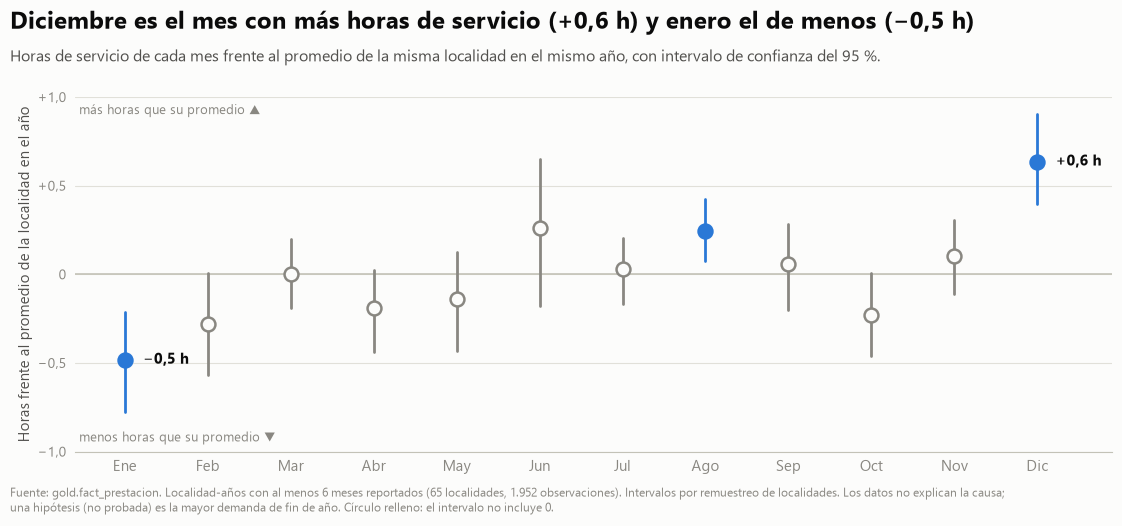

In [24]:
mostrar("fig11_estacionalidad")

In [25]:
s = H["estacionalidad"]
mes = ["", "enero", "febrero", "marzo", "abril", "mayo", "junio", "julio", "agosto", "septiembre", "octubre", "noviembre", "diciembre"]
md(f"""
**Lectura.** Hay un patrón estacional pequeño pero claro: **{mes[s['mes_mas_alto']]}** es el mes con más horas ({signo(s['valor_mas_alto'])} h frente al promedio de la misma localidad ese año)
y **{mes[s['mes_mas_bajo']]}** el de menos ({signo(s['valor_mas_bajo'])} h). Los intervalos de confianza de ambos meses no incluyen el cero (ver figura). Los datos no dicen por qué (una hipótesis, sin probar, es la
mayor demanda de fin de año).
""")


**Lectura.** Hay un patrón estacional pequeño pero claro: **diciembre** es el mes con más horas (+0,6 h frente al promedio de la misma localidad ese año)
y **enero** el de menos (−0,5 h). Los intervalos de confianza de ambos meses no incluyen el cero (ver figura). Los datos no dicen por qué (una hipótesis, sin probar, es la
mayor demanda de fin de año).


### P4 · ¿Qué operador presta el servicio y cómo se comparan las horas entre operadores?

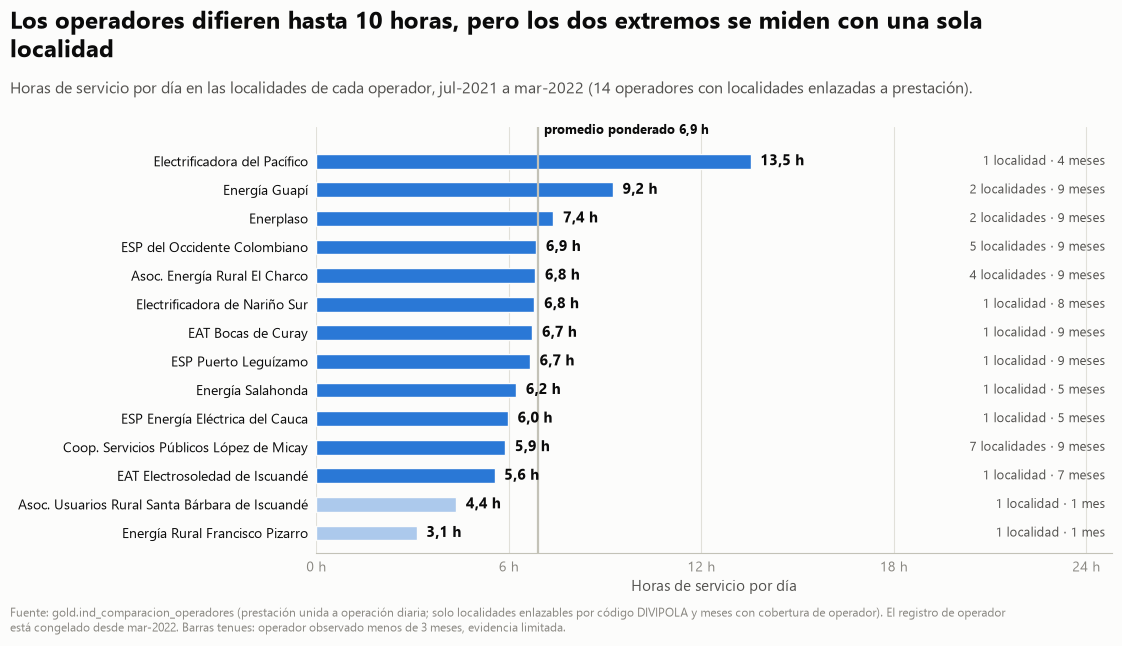

In [26]:
mostrar("fig12_operadores")

In [27]:
o = H["operadores"]
md(f"""
**Lectura.** Con {o['total']} operadores observados entre {o['periodo_desde']} y {o['periodo_hasta']}, el que más horas tiene es **{o['mejor']['nombre']}** ({horas(o['mejor']['horas'])}) y el que menos, **{o['peor']['nombre']}** ({horas(o['peor']['horas'])}).
Pero **ambos extremos se miden con {o['mejor']['localidades']} localidad** y entre {o['peor']['meses']} y {o['mejor']['meses']} meses: no alcanza para decir que un operador sea mejor que otro. Además solo
se puede asignar operador al {num(o['pct_localidades_con_operador_enlazable'], 0)} % de las localidades (las enlazables por código DIVIPOLA) y el registro está congelado desde {o['periodo_hasta']}.
""")


**Lectura.** Con 14 operadores observados entre 2021-07 y 2022-03, el que más horas tiene es **Electrificadora del Pacífico** (13,5 h) y el que menos, **Energía Rural Francisco Pizarro** (3,1 h).
Pero **ambos extremos se miden con 1 localidad** y entre 1 y 4 meses: no alcanza para decir que un operador sea mejor que otro. Además solo
se puede asignar operador al 52 % de las localidades (las enlazables por código DIVIPOLA) y el registro está congelado desde 2022-03.


### P5 · ¿Qué empresas y municipios concentran más PQR y cómo se comparan con las horas de servicio?

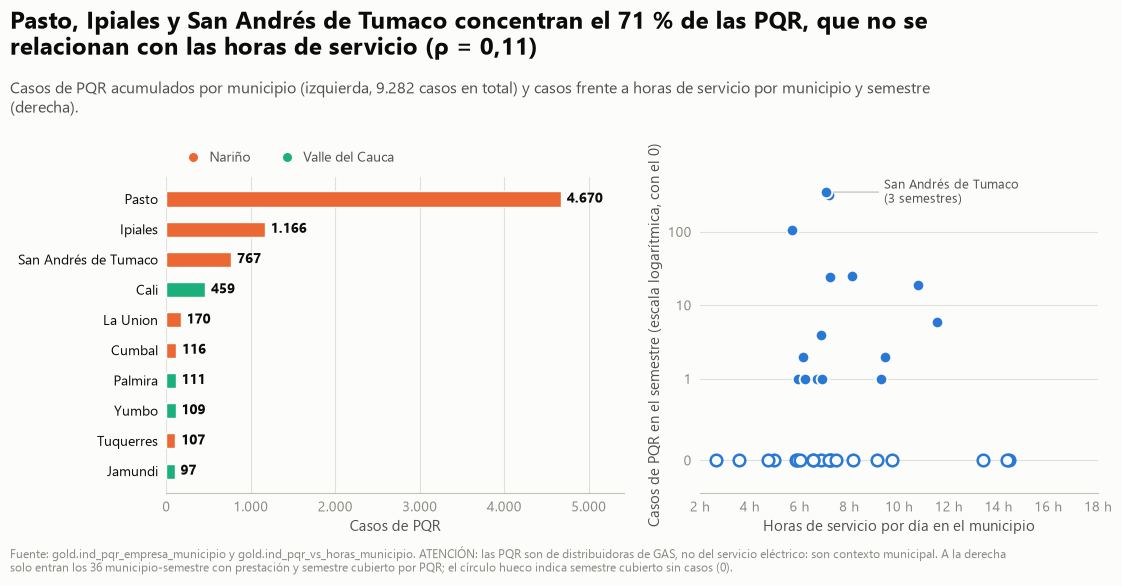

In [28]:
mostrar("fig13_pqr")

In [29]:
p = H["pqr"]
md(f"""
**Lectura.** Hay **{num(p['total'])} casos de PQR** en la región (el {num(p['pct_con_respuesta'], 0)} % con respuesta), y **{', '.join(p['tres_municipios_con_mas_casos'])}** concentran el {num(p['participacion_tres_municipios_pct'], 0)} %.
La relación con las horas de servicio es débil (ρ = {num(p['correlacion_con_horas']['rho'], 2)} con {p['correlacion_con_horas']['pares']} pares municipio-semestre).

> **Advertencia:** las empresas de esta fuente son distribuidoras de **gas**, no operadores eléctricos (el identificador de empresa coincide en 0 % con la bitácora de operación). Las PQR sirven como
> contexto municipal de servicios públicos; **no miden la calidad del servicio de energía**, y por eso la relación con las horas no es una prueba de nada.
""")


**Lectura.** Hay **9.282 casos de PQR** en la región (el 89 % con respuesta), y **Pasto, Ipiales, San Andrés de Tumaco** concentran el 71 %.
La relación con las horas de servicio es débil (ρ = 0,11 con 36 pares municipio-semestre).

> **Advertencia:** las empresas de esta fuente son distribuidoras de **gas**, no operadores eléctricos (el identificador de empresa coincide en 0 % con la bitácora de operación). Las PQR sirven como
> contexto municipal de servicios públicos; **no miden la calidad del servicio de energía**, y por eso la relación con las horas no es una prueba de nada.


### P6 · ¿Qué municipios tienen el peor desempeño combinado y cuáles de sus localidades tienen menos horas?

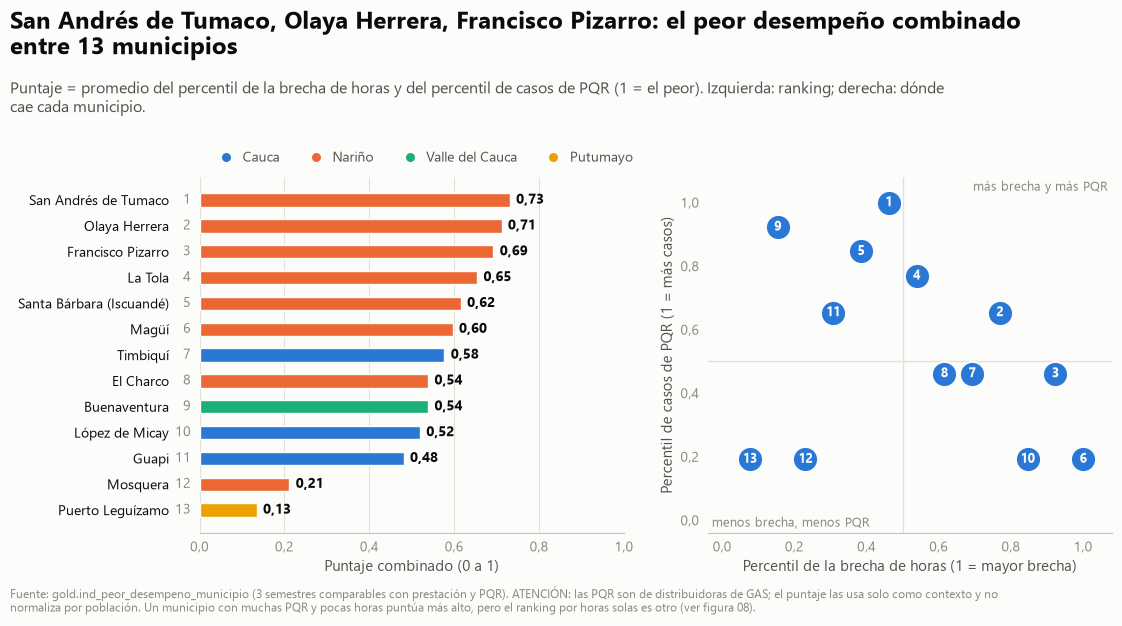

In [30]:
mostrar("fig14_peor_desempeno")

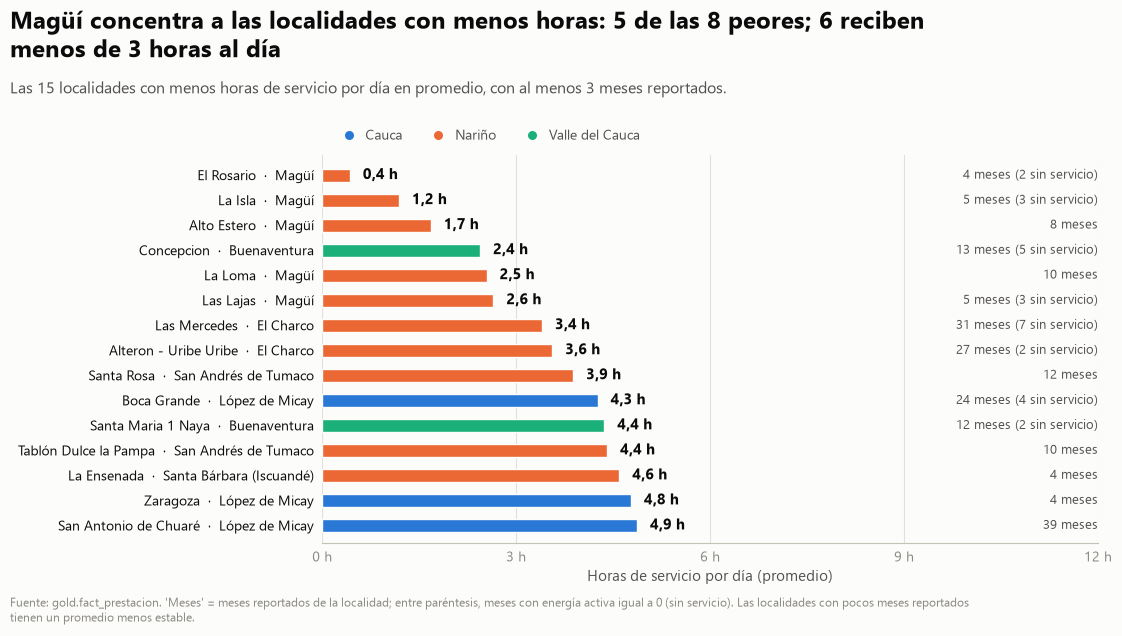

In [31]:
mostrar("fig15_localidades_menos_horas")

In [32]:
pc = H["peor_desempeno_combinado"]
lm = H["localidades_menos_horas"]
en_municipio = sum(1 for x in lm if x["municipio"] == lm[0]["municipio"])
md(f"""
**Lectura.** El puntaje combinado (promedio del percentil de brecha de horas y del percentil de PQR) pone primero a **{pc[0]['municipio']}**, seguido de {pc[1]['municipio']} y {pc[2]['municipio']}.
Pero {pc[0]['municipio']} encabeza sobre todo por sus {num(pc[0]['n_pqr'])} casos de PQR (de gas), mientras que {pc[1]['municipio']} y {pc[2]['municipio']} lo hacen por su brecha de horas
({pc[1]['n_pqr']} y {pc[2]['n_pqr']} casos de PQR).
Si se mira **solo el servicio eléctrico**, el cuadro es otro: las localidades con menos horas son {lm[0]['localidad']} ({horas(lm[0]['horas'])}), {lm[1]['localidad']} ({horas(lm[1]['horas'])}) y {lm[2]['localidad']} ({horas(lm[2]['horas'])}),
y {en_municipio} de las {len(lm)} localidades con menos horas son de **{lm[0]['municipio']}**.
""")


**Lectura.** El puntaje combinado (promedio del percentil de brecha de horas y del percentil de PQR) pone primero a **San Andrés de Tumaco**, seguido de Olaya Herrera y Francisco Pizarro.
Pero San Andrés de Tumaco encabeza sobre todo por sus 767 casos de PQR (de gas), mientras que Olaya Herrera y Francisco Pizarro lo hacen por su brecha de horas
(3 y 1 casos de PQR).
Si se mira **solo el servicio eléctrico**, el cuadro es otro: las localidades con menos horas son El Rosario (0,4 h), La Isla (1,2 h) y Alto Estero (1,7 h),
y 5 de las 8 localidades con menos horas son de **Magüí**.


## 5. Contexto: la bitácora de operación diaria

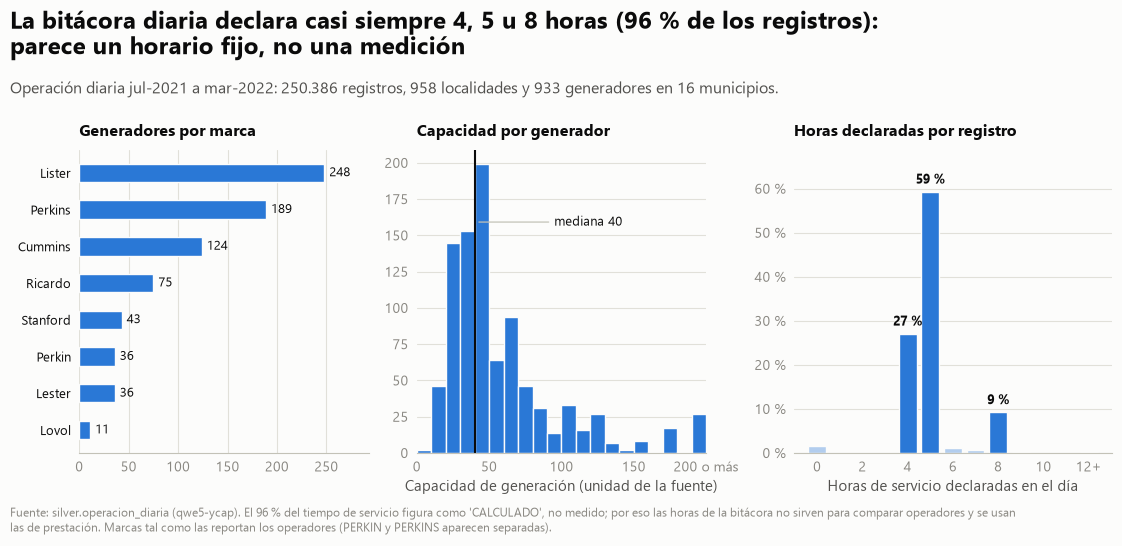

In [33]:
mostrar("fig16_operacion_diaria")

In [34]:
d = H["operacion_diaria"]
md(f"""
**Lectura.** La bitácora (`operacion_diaria`) es la fuente más detallada: **{num(d['registros'])} registros**, **{num(d['localidades'])} localidades** (frente a {a['localidades']} en `prestacion`) y **{num(d['generadores'])} generadores**
de capacidad mediana {num(d['capacidad_mediana'], 0)} (en la unidad de la fuente). Sin embargo, el **{num(d['pct_4_5_u_8_horas'], 0)} %** de los registros declara 4, 5 u 8 horas y el {num(d['pct_calculado'], 0)} % del tiempo de servicio
figura como *calculado*: parece un horario fijo, no una medición. Por eso las horas de servicio del análisis salen de `prestacion` y la bitácora se usa solo para saber **quién opera** cada localidad.
""")


**Lectura.** La bitácora (`operacion_diaria`) es la fuente más detallada: **250.386 registros**, **958 localidades** (frente a 97 en `prestacion`) y **933 generadores**
de capacidad mediana 40 (en la unidad de la fuente). Sin embargo, el **96 %** de los registros declara 4, 5 u 8 horas y el 96 % del tiempo de servicio
figura como *calculado*: parece un horario fijo, no una medición. Por eso las horas de servicio del análisis salen de `prestacion` y la bitácora se usa solo para saber **quién opera** cada localidad.


## 6. Conclusiones, límites y siguientes pasos

In [35]:
kp = H["kpis_pipeline"]
cumplen = sum(1 for v in kp.values() if v["cumple"])
md(f"""
### Qué encontramos
1. **El servicio es corto en todo el suroccidente:** {horas(er['region']['horas'])} de 24 horas en promedio (último año con datos); Cauca y Nariño, menos de 7 horas.
2. **La brecha se concentra en la costa pacífica de Nariño y Cauca**, con {m[0]['municipio']} como caso extremo ({horas(m[0]['horas'])}); las localidades con menos horas están allí.
3. **No hay mejora generalizada:** el cambio mediano por localidad es de {signo(cl['mediana'])} h (intervalo del 95 %: {signo(cl['mediana_inferior'])} a {signo(cl['mediana_superior'])}). Solo {mm[0]['localidad']} y {mm[1]['localidad']} mejoraron de forma notable.
4. **Hay estacionalidad:** {mes[s['mes_mas_alto']]} es el mejor mes ({signo(s['valor_mas_alto'])} h) y {mes[s['mes_mas_bajo']]} el peor ({signo(s['valor_mas_bajo'])} h).
5. **La energía está muy concentrada** ({e['localidades_para_80_pct']} localidades acumulan el 80 %), así que se compara por horas, no por energía.

### Qué limita estas conclusiones
- **Datos atrasados:** `prestacion` lleva {f['prestacion']['meses_sin_datos_nuevos']} meses sin datos nuevos; `operacion_diaria` y `pqr` están congeladas.
- **Cobertura irregular:** entre {c['minimo']} y {c['maximo']} de {a['localidades']} localidades reportan cada mes.
- **Las PQR son de gas**, no del servicio eléctrico.
- **Pocas localidades por operador** y registro de operador congelado.
- Sin fuente de **población** ni catálogo **DIVIPOLA**: no se puede normalizar por habitantes ni validar los códigos contra un catálogo oficial.

### Siguientes pasos
- Incorporar población por localidad (DANE) para medir *población atendida* y priorizar inversión (KPI de fase 2 del diseño).
- Investigar qué cambió en {mm[0]['localidad']} y {mm[1]['localidad']} (proyectos, tecnología, operador) para replicarlo.
- Publicar el tablero en Power BI sobre el esquema `gold` y mostrar las advertencias de frescura de `meta_fuentes`.

**Calidad del pipeline:** {cumplen} de {len(kp)} indicadores del pipeline cumplen su meta (integración, estandarización, duplicados, trazabilidad, completitud, errores, reglas documentadas y reproducibilidad).
""")


### Qué encontramos
1. **El servicio es corto en todo el suroccidente:** 7,8 h de 24 horas en promedio (último año con datos); Cauca y Nariño, menos de 7 horas.
2. **La brecha se concentra en la costa pacífica de Nariño y Cauca**, con Magüí como caso extremo (1,9 h); las localidades con menos horas están allí.
3. **No hay mejora generalizada:** el cambio mediano por localidad es de +0,3 h (intervalo del 95 %: −0,6 a +1,0). Solo Puerto Merizalde y Pital de la Costa mejoraron de forma notable.
4. **Hay estacionalidad:** diciembre es el mejor mes (+0,6 h) y enero el peor (−0,5 h).
5. **La energía está muy concentrada** (5 localidades acumulan el 80 %), así que se compara por horas, no por energía.

### Qué limita estas conclusiones
- **Datos atrasados:** `prestacion` lleva 8 meses sin datos nuevos; `operacion_diaria` y `pqr` están congeladas.
- **Cobertura irregular:** entre 14 y 44 de 97 localidades reportan cada mes.
- **Las PQR son de gas**, no del servicio eléctrico.
- **Pocas localidades por operador** y registro de operador congelado.
- Sin fuente de **población** ni catálogo **DIVIPOLA**: no se puede normalizar por habitantes ni validar los códigos contra un catálogo oficial.

### Siguientes pasos
- Incorporar población por localidad (DANE) para medir *población atendida* y priorizar inversión (KPI de fase 2 del diseño).
- Investigar qué cambió en Puerto Merizalde y Pital de la Costa (proyectos, tecnología, operador) para replicarlo.
- Publicar el tablero en Power BI sobre el esquema `gold` y mostrar las advertencias de frescura de `meta_fuentes`.

**Calidad del pipeline:** 8 de 8 indicadores del pipeline cumplen su meta (integración, estandarización, duplicados, trazabilidad, completitud, errores, reglas documentadas y reproducibilidad).
